# Student Social Media Addiction - Data Analysis & Classification

In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/Students Social Media Addiction.csv")

# Encode categorical columns
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})

# Drop missing values
df.dropna(inplace=True)

# Relabel Addicted_Score to start from 1
df['Addicted_Score'] = df['Addicted_Score'] - df['Addicted_Score'].min() + 1


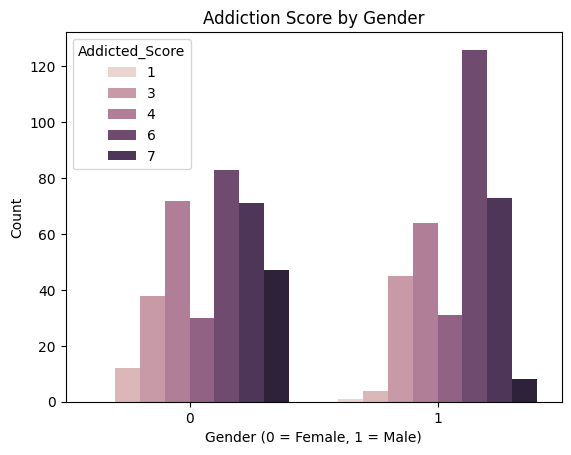

In [5]:

sns.countplot(data=df, x='Gender', hue='Addicted_Score')
plt.title("Addiction Score by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


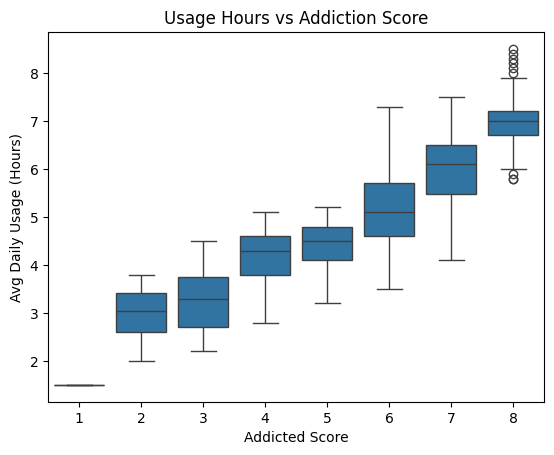

In [6]:

sns.boxplot(data=df, x='Addicted_Score', y='Avg_Daily_Usage_Hours')
plt.title("Usage Hours vs Addiction Score")
plt.xlabel("Addicted Score")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


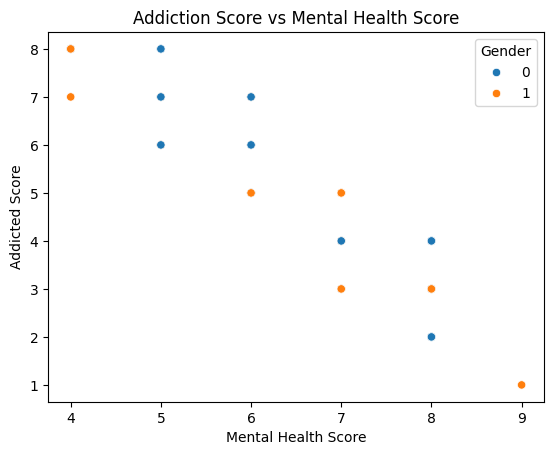

In [7]:

sns.scatterplot(data=df, x='Mental_Health_Score', y='Addicted_Score', hue='Gender')
plt.title("Addiction Score vs Mental Health Score")
plt.xlabel("Mental Health Score")
plt.ylabel("Addicted Score")
plt.show()


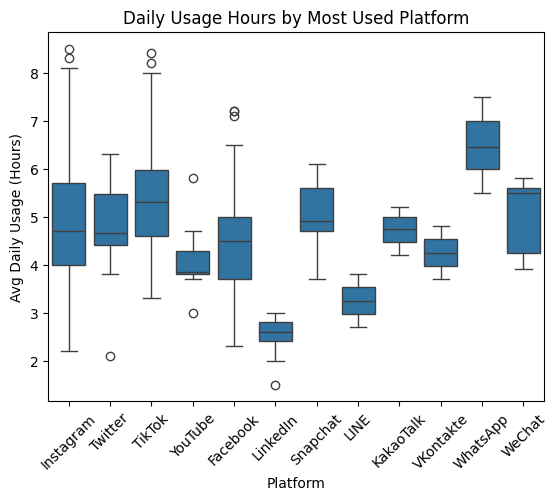

In [8]:

sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.xticks(rotation=45)
plt.title("Daily Usage Hours by Most Used Platform")
plt.xlabel("Platform")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


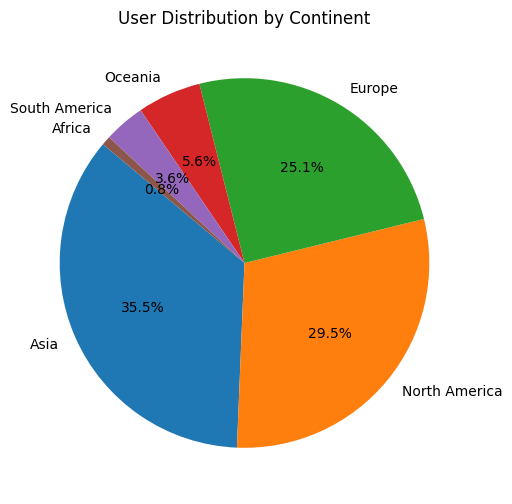

In [9]:

continent_map = {
    'USA': 'North America', 'Canada': 'North America',
    'India': 'Asia', 'Bangladesh': 'Asia', 'China': 'Asia',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Australia': 'Oceania', 'Nigeria': 'Africa', 'South Africa': 'Africa'
}
df['Continent'] = df['Country'].map(continent_map)
continent_counts = df['Continent'].value_counts().dropna()

plt.figure(figsize=(6,6))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("User Distribution by Continent")
plt.show()


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get dummies and scale
df = pd.get_dummies(df, columns=['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status'], drop_first=True)
X = df.drop(columns=['Student_ID', 'Addicted_Score', 'Continent'], errors='ignore')
y = df['Addicted_Score'] - 1  # Now starts from 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


In [11]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_lstm, y_train, epochs=30, batch_size=32, validation_data=(X_test_lstm, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.2248 - loss: 2.0366 - val_accuracy: 0.4255 - val_loss: 1.8989
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4655 - loss: 1.8478 - val_accuracy: 0.5532 - val_loss: 1.7072
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5413 - loss: 1.6102 - val_accuracy: 0.5816 - val_loss: 1.4743
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6424 - loss: 1.3471 - val_accuracy: 0.6454 - val_loss: 1.2542
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6464 - loss: 1.1418 - val_accuracy: 0.6879 - val_loss: 1.0474
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6986 - loss: 0.9602 - val_accuracy: 0.7801 - val_loss: 0.8596
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7883 - loss: 0.7662 - val_accuracy: 0.8156 - val_loss: 0.6999
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8362 - loss: 0.6596 - val_accuracy: 0.8511 - val_lo

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9059 - loss: 0.2760 
Test Accuracy: 0.8936


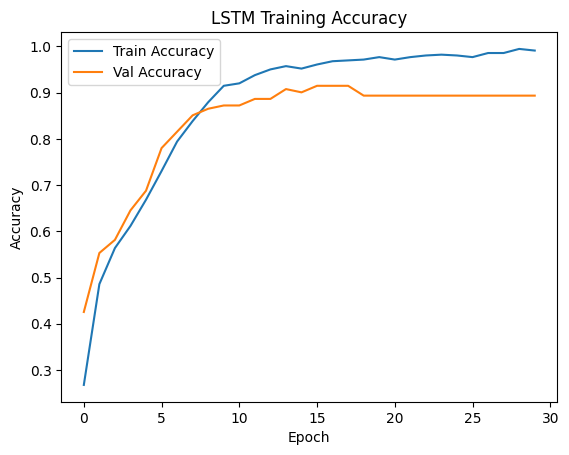

In [12]:

loss, accuracy = model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot history
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       0.89      0.89      0.89         9
           5       0.97      0.88      0.92        41
           6       0.84      0.75      0.79        28
           7       0.59      1.00      0.74        10

    accuracy                           0.89       141
   macro avg       0.77      0.81      0.78       141
weighted avg       0.90      0.89      0.89       141



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


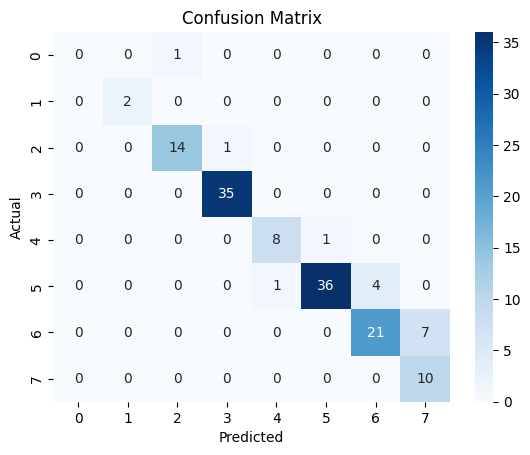

In [13]:

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_labels))

conf_matrix = confusion_matrix(y_test, y_pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
